In [343]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans




In [344]:
# Import the data

df = pd.read_csv('data/data_cleaned_for_clustering.csv')
df.head()

,Unnamed: 0,age,job,day_of_week,campaign,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,default_status_known,was_previously_contacted,positive_campaign_result
0,0,56,housemaid,mon,1,0,no,no,no,-36.4,4.857,married,basic.4y,0,telephone,may,261,1,0,0
1,1,57,services,mon,1,0,no,no,unknown,-36.4,4.857,married,high.school,0,telephone,may,149,0,0,0
2,2,37,services,mon,1,0,yes,no,no,-36.4,4.857,married,high.school,0,telephone,may,226,1,0,0
3,3,40,admin.,mon,1,0,no,no,no,-36.4,4.857,married,basic.6y,0,telephone,may,151,1,0,0
4,4,56,services,mon,1,0,no,yes,no,-36.4,4.857,married,high.school,0,telephone,may,307,1,0,0


In [345]:
# Drop two unnecessary columns

df = df.drop(columns=['Unnamed: 0', 'default_status_known', 'day_of_week'])

In [346]:
# Inititate the variable for categorical and numeric column

target_cols = ['term_deposit_subscribed', 'positive_campaign_result']

numeric_cols = df.select_dtypes(include='number').columns.tolist()
# numeric_cols = [c for c in numeric_cols if c not in target_cols]

categorical_cols = df.select_dtypes(include='object').columns.tolist()
# categorical_cols = [c for c in categorical_cols if c not in target_cols]

In [347]:
# verify categorical features

categorical_cols

['job',
 'has_housing_loan',
 'has_personal_loan',
 'default_status',
 'marital_status',
 'education_level',
 'communication_type',
 'last_contact_month']

In [348]:
# Verify numeric features

numeric_cols

['age',
 'campaign',
 'term_deposit_subscribed',
 'consumer_confidence_index',
 'euribor_3mo_rate',
 'previous_contacted',
 'last_contact_duration_sec',
 'was_previously_contacted',
 'positive_campaign_result']

In [349]:
# Sub-pipelines built with make_pipeline

numeric_pipeline = make_pipeline(StandardScaler())
categorical_pipeline = make_pipeline(OneHotEncoder(handle_unknown='ignore', sparse_output=False))



In [350]:
# ColumnTransformer still does the split/rejoin

preprocessing_pipeline = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])


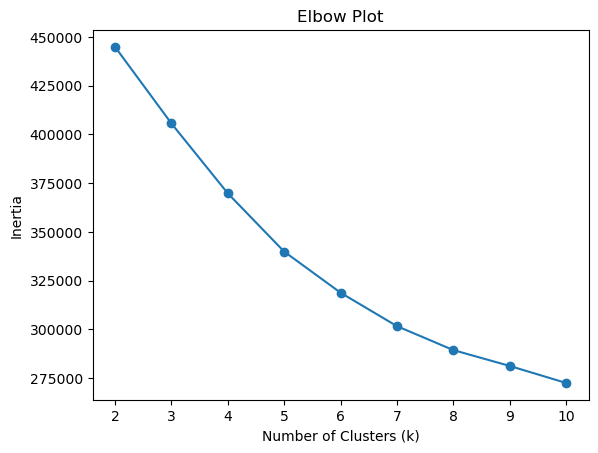

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Combined Data frame
X = df[numeric_cols + categorical_cols]


# Fit and transform once
X_processed = preprocessing_pipeline.fit_transform(X)

# Then compute inertias
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_processed)
    inertias.append(km.inertia_)

# Plot
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot')
plt.xticks(k_range)
plt.show()

In [ ]:
# Full end-to-end pipeline including KMeans


from sklearn.decomposition import PCA

full_pipeline = make_pipeline(
    preprocessing_pipeline,
    PCA(n_components=10, random_state=42),
    KMeans(n_clusters=4, random_state=42, n_init=10)
)

In [ ]:
# Fit the full pipeline and assign clusters
full_pipeline.fit(X)
df['cluster'] = full_pipeline.named_steps['kmeans'].labels_

In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39803 entries, 0 to 39802
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        39803 non-null  int64  
 1   job                        39803 non-null  object 
 2   campaign                   39803 non-null  int64  
 3   term_deposit_subscribed    39803 non-null  int64  
 4   has_housing_loan           39803 non-null  object 
 5   has_personal_loan          39803 non-null  object 
 6   default_status             39803 non-null  object 
 7   consumer_confidence_index  39803 non-null  float64
 8   euribor_3mo_rate           39803 non-null  float64
 9   marital_status             39803 non-null  object 
 10  education_level            39803 non-null  object 
 11  previous_contacted         39803 non-null  int64  
 12  communication_type         39803 non-null  object 
 13  last_contact_month         39803 non-null  obj

In [355]:
df.head()

,age,job,campaign,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,was_previously_contacted,positive_campaign_result,cluster
0,56,housemaid,1,0,no,no,no,-36.4,4.857,married,basic.4y,0,telephone,may,261,0,0,1
1,57,services,1,0,no,no,unknown,-36.4,4.857,married,high.school,0,telephone,may,149,0,0,1
2,37,services,1,0,yes,no,no,-36.4,4.857,married,high.school,0,telephone,may,226,0,0,1
3,40,admin.,1,0,no,no,no,-36.4,4.857,married,basic.6y,0,telephone,may,151,0,0,1
4,56,services,1,0,no,yes,no,-36.4,4.857,married,high.school,0,telephone,may,307,0,0,1


In [356]:
from sklearn.metrics import silhouette_score

# X_processed = preprocessing_pipeline.fit_transform(X)
score = silhouette_score(X_processed, df['cluster'])
print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.1932


In [358]:
# Extract the PCA transformed data from your existing pipeline
X_processed = preprocessing_pipeline.transform(X)
X_pca = full_pipeline.named_steps['pca'].transform(X_processed)

# Then fit Agglomerative on that
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=4)
df['cluster_agg'] = agg.fit_predict(X_pca)

# Score it
score = silhouette_score(X_pca, df['cluster_agg'])
print(f'Agglomerative Silhouette: {score:.4f}')

Agglomerative Silhouette: 0.2846


In [ ]:
# See optimal num of clusters 

for linkage in ['ward', 'complete', 'average']:
    for k in range(2, 8):
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = agg.fit_predict(X_pca)
        score = silhouette_score(X_pca, labels)
        print(f'linkage={linkage} | k={k} | Silhouette: {score:.4f}')

linkage=ward | k=2 | Silhouette: 0.4092
linkage=ward | k=3 | Silhouette: 0.2589
linkage=ward | k=4 | Silhouette: 0.2846
linkage=ward | k=5 | Silhouette: 0.2530
linkage=ward | k=6 | Silhouette: 0.2575
linkage=ward | k=7 | Silhouette: 0.1856
linkage=complete | k=2 | Silhouette: 0.6877
linkage=complete | k=3 | Silhouette: 0.5190
linkage=complete | k=4 | Silhouette: 0.5156
linkage=complete | k=5 | Silhouette: 0.4809
linkage=complete | k=6 | Silhouette: 0.3565
linkage=complete | k=7 | Silhouette: 0.3253
linkage=average | k=2 | Silhouette: 0.7176
linkage=average | k=3 | Silhouette: 0.5316
linkage=average | k=4 | Silhouette: 0.5218
linkage=average | k=5 | Silhouette: 0.5039
linkage=average | k=6 | Silhouette: 0.4499
linkage=average | k=7 | Silhouette: 0.4432


In [380]:
# Using average linkag w/ agglomerative clustering  and 4 clusters for granualrity vs score

agg_final = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster'] = agg_final.fit_predict(X_pca)

score = silhouette_score(X_pca, df['cluster'])
print(f'Final Silhouette: {score:.4f}')

Final Silhouette: 0.2589


In [381]:
# Check percentage of data in each cluster

df['cluster'].value_counts(normalize=True).mul(100).round(2)

cluster
2    65.45
1    20.90
0    13.65
Name: proportion, dtype: float64

In [377]:
df.head()

,age,job,campaign,term_deposit_subscribed,has_housing_loan,has_personal_loan,default_status,consumer_confidence_index,euribor_3mo_rate,marital_status,education_level,previous_contacted,communication_type,last_contact_month,last_contact_duration_sec,was_previously_contacted,positive_campaign_result,cluster
0,56,housemaid,1,0,no,no,no,-36.4,4.857,married,basic.4y,0,telephone,may,261,0,0,0
1,57,services,1,0,no,no,unknown,-36.4,4.857,married,high.school,0,telephone,may,149,0,0,0
2,37,services,1,0,yes,no,no,-36.4,4.857,married,high.school,0,telephone,may,226,0,0,0
3,40,admin.,1,0,no,no,no,-36.4,4.857,married,basic.6y,0,telephone,may,151,0,0,0
4,56,services,1,0,no,yes,no,-36.4,4.857,married,high.school,0,telephone,may,307,0,0,0


In [384]:
import joblib

# Save preprocessing pipeline (scaler + encoder)
joblib.dump(preprocessing_pipeline, 'Models/preprocessing_pipeline.pkl')

# Save PCA
joblib.dump(full_pipeline.named_steps['pca'], 'Models/pca.pkl')

# Save final clustering model
joblib.dump(agg_final, 'Models/agglomerative_model.pkl')

# Save column lists so you know exactly what X looks like
joblib.dump(numeric_cols, 'Models/numeric_cols.pkl')
joblib.dump(categorical_cols, 'Models/categorical_cols.pkl')


['Models/categorical_cols.pkl']

In [ ]:
# Save final file w/ clsutering label

df.to_csv('data/clustered_data.csv')